In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import math

import plotly.io as pio
pio.renderers.default = "browser"

%matplotlib inline

We start with the damped harmonic oscillator. 

$$
\begin{split}
\frac{dx}{dt} = 
\end{split}
$$

In [2]:
def solve_and_plot(system, t_span, initial_conditions, t_eval=None, grid_size=20, time_points=1000, rtol=1e-9, atol=1e-12, max_step=np.inf, fixed_points=None, plot_vectorfield=True):
    """
    Solve and visualize a 2D or 3D nonlinear dynamical system with higher time resolution.

    Parameters:
    - system: function(t, y) -> list/array
    - t_span: tuple (t0, tf)
    - initial_conditions: array-like of shape (N, dim)
    - t_eval: optional array of time points (overrides time_points if provided)
    - grid_size: resolution of vector field grid
    - time_points: number of time samples if t_eval is None
    - rtol, atol: solver tolerances (tighter = higher accuracy)
    - max_step: maximum internal solver step size (reduce for finer resolution)
    """

    initial_conditions = np.array(initial_conditions)
    dim = initial_conditions.shape[1]

    if dim not in [2, 3]:
        raise ValueError("Only 2D or 3D systems are supported.")

    # --- Build high-resolution time grid if not provided ---
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], time_points)

    # --- First: integrate trajectories to determine bounds ---
    trajectories = []
    all_points = []

    for y0 in initial_conditions:
        sol = solve_ivp(
            system,
            t_span,
            y0,
            t_eval=t_eval,
            rtol=rtol,
            atol=atol,
            max_step=max_step
        )
        trajectories.append(sol)
        all_points.append(sol.y.T)

    all_points = np.vstack(all_points)

    # Determine dynamic plotting bounds based on trajectories
    mins = all_points.min(axis=0)
    maxs = all_points.max(axis=0)

    # Add margin so vectors are not clipped
    margins = 0.1 * (maxs - mins + 1e-6)
    mins -= margins
    maxs += margins

    # --- Generate vector field grid using trajectory-informed bounds ---
    ranges = [np.linspace(mins[d], maxs[d], grid_size) for d in range(dim)]
    mesh = np.meshgrid(*ranges)

    # Flatten grid for evaluation
    points = np.vstack([m.flatten() for m in mesh]).T
    vectors = np.array([system(0, p) for p in points])

    # --- Plotting ---
    fig = plt.figure(figsize=(8, 6))

    if dim == 2:
        X, Y = mesh
        U = vectors[:, 0].reshape(X.shape)
        V = vectors[:, 1].reshape(Y.shape)

        if plot_vectorfield:
            plt.quiver(X, Y, U, V, alpha=0.4)

        # Plot trajectories
        for sol, y0 in zip(trajectories, initial_conditions):
            plt.plot(sol.y[0], sol.y[1])
            plt.scatter(y0[0], y0[1])
        
        if fixed_points is not None:
            for fixed_point in fixed_points:
                if fixed_point[0] == 'stable':
                    plt.scatter(fixed_point[1][0], fixed_point[1][1], c='k', s=30)
                elif fixed_point[0] == 'unstable':
                    plt.scatter(fixed_point[1][0], fixed_point[1][1], facecolor='white', edgecolor='black', s=30)

        plt.xlim(mins[0], maxs[0])
        plt.ylim(mins[1], maxs[1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Phase Space (2D)')
        plt.grid()

    elif dim == 3:
        from mpl_toolkits.mplot3d import Axes3D
        ax = fig.add_subplot(111, projection='3d')

        X, Y, Z = mesh
        U = vectors[:, 0].reshape(X.shape)
        V = vectors[:, 1].reshape(Y.shape)
        W = vectors[:, 2].reshape(Z.shape)

        if plot_vectorfield:
            ax.quiver(X, Y, Z, U, V, W, length=0.5, normalize=True, alpha=0.4)

        # Plot trajectories
        for sol, y0 in zip(trajectories, initial_conditions):
            ax.plot(sol.y[0], sol.y[1], sol.y[2])
            ax.scatter(y0[0], y0[1], y0[2])

        if fixed_points is not None:
            for fixed_point in fixed_points:
                if fixed_point[0] == 'stable':
                    ax.scatter(fixed_point[1][0], fixed_point[1][1], fixed_point[1][2], c='k', s=30)
                elif fixed_point[0] == 'unstable':
                    ax.scatter(fixed_point[1][0], fixed_point[1][1], fixed_point[1][2], facecolor='white', edgecolor='black', s=30)

        ax.set_xlim(mins[0], maxs[0])
        ax.set_ylim(mins[1], maxs[1])
        ax.set_zlim(mins[2], maxs[2])
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Phase Space (3D)')

    plt.tight_layout()
    plt.show()


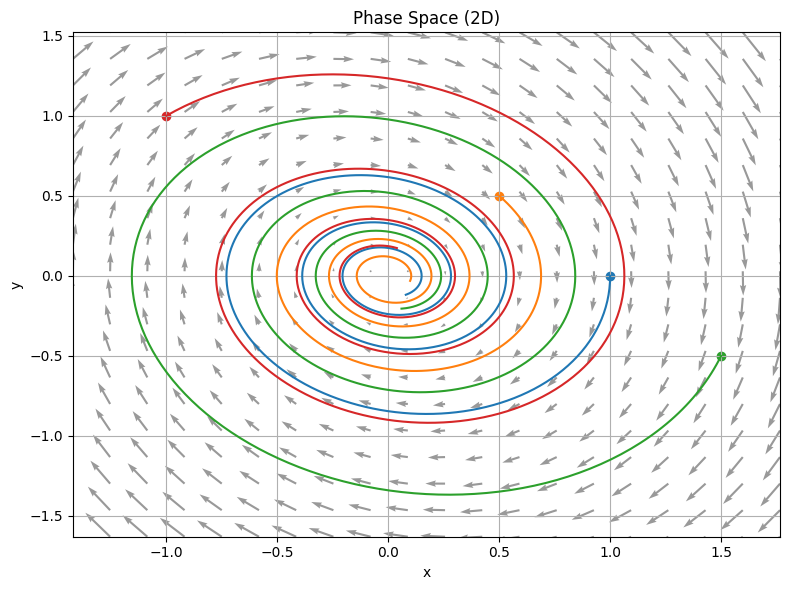

In [3]:
def damped_harmonic_oscillator(t, y, zeta=0.1):
    """
    Dimensionless damped harmonic oscillator:

        x'' + 2*zeta*x' + x = 0

    Converted to first-order system:
        x' = v
        v' = -2*zeta*v - x

    Parameters:
    - zeta: damping ratio
    """
    x, v = y
    dxdt = v
    dvdt = -2 * zeta * v - x
    return [dxdt, dvdt]

#Example initial conditions (for notebook use):
initial_conditions = [
     [1.0, 0.0],
    [0.5, 0.5],
    [1.5, -0.5],
    [-1.0, 1.0]
]

#Example call (in notebook):
solve_and_plot(damped_harmonic_oscillator, t_span=(0, 20), initial_conditions=initial_conditions)

now with driving

In [4]:
zeta = 0.1
alpha = 5
delta = -4

def driven_DHO(t, y):
    x, v = y
    dxdt = v
    dvdt = -2 * zeta * v - x + alpha / ((x+delta)**2+1)
    return [dxdt, dvdt]

def x_star(alpha, delta):
    roots = np.roots([1, 2*delta, delta**2 + 1, -1*alpha])
    roots[~np.isreal(roots)] = np.nan
    return np.real(roots)

In [5]:
roots = x_star(alpha, delta)

fixed_points = []

#check stability
for x in roots:
    if not np.isnan(x):
        eigenvalues, eigenvectors = np.linalg.eig(np.array([[0, 1],
                                              [-1 - 2*alpha*(x+delta) / ((x+delta)**2+1)**2, -2*zeta]]))
        if np.real(eigenvalues)[0] < 0 and np.real(eigenvalues)[1] < 0:
            fixed_points.append(('stable', (x, 0)))
        else:
            fixed_points.append(('unstable', (x, 0)))

fixed_points
    

[('stable', (np.float64(4.37720285397294), 0)),
 ('unstable', (np.float64(3.273890554964227), 0)),
 ('stable', (np.float64(0.3489065910628246), 0))]

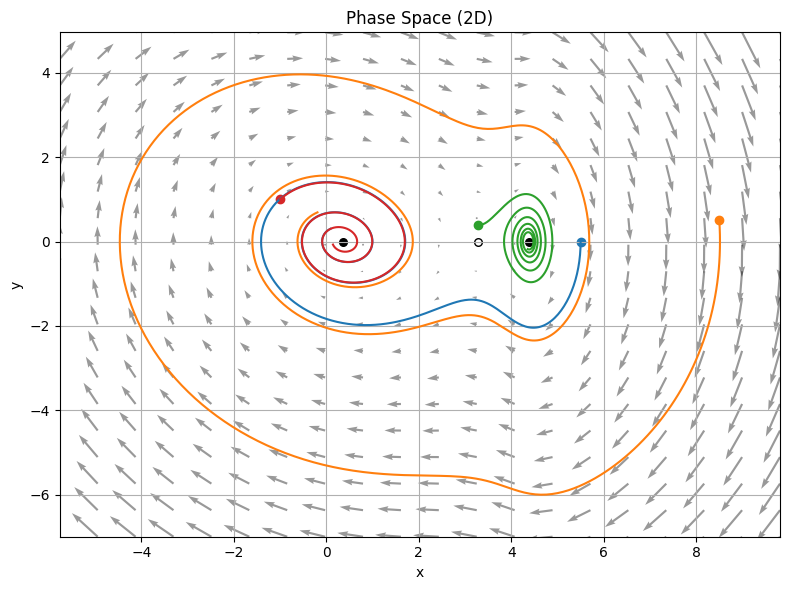

In [6]:
#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0],
    [8.5, 0.5],
    [3.27, 0.4],
    [-1.0, 1.0]
]


solve_and_plot(driven_DHO, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points)

3.8851326820537975
[-0.1+0.33026329j -0.1-0.33026329j]
3.851824575229439
[ 0.25632485 -0.45632485]
0.2630427427167583
[-0.1+0.92662194j -0.1-0.92662194j]


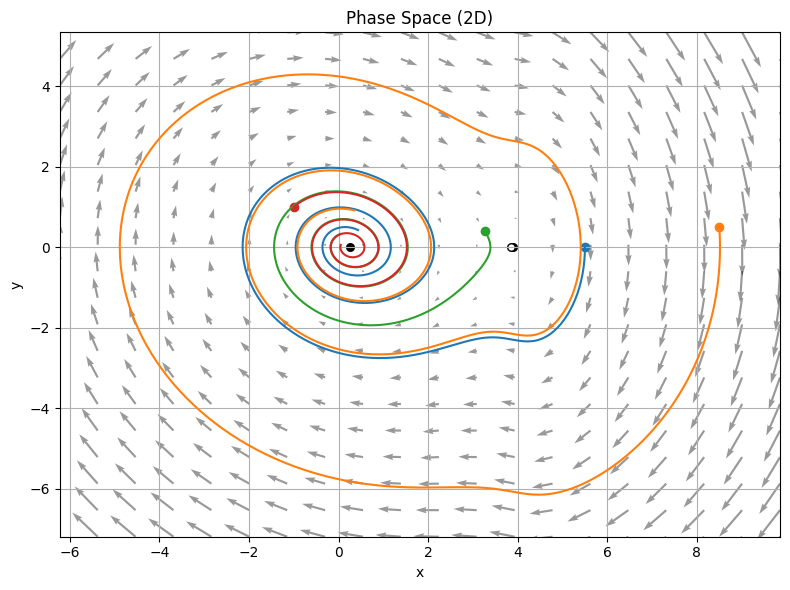

In [7]:
def bifurcation(d):
    return 2/27 * (-1*(d**3+9*d) + (3-d**2)*np.sqrt(d**2 - 3))

zeta=0.1
delta=-4
alpha = bifurcation(delta)+0.001

#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0],
    [8.5, 0.5],
    [3.27, 0.4],
    [-1.0, 1.0]
]

roots = x_star(alpha, delta)

fixed_points = []

for x in roots:
    print(x)
    if not np.isnan(x):
        eigenvalues, eigenvectors = np.linalg.eig(np.array([[0, 1],
                                              [-1 - 2*alpha*(x+delta) / ((x+delta)**2+1)**2, -2*zeta]]))
        print(eigenvalues)
        if np.real(eigenvalues)[0] < 0 and np.real(eigenvalues)[1] < 0:
            fixed_points.append(('stable', (x, 0)))
        else:
            fixed_points.append(('unstable', (x, 0)))


solve_and_plot(driven_DHO, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points)

In [8]:
def bifurcation_plot(A_range, delta_range, resolution=150):

    A = np.linspace(*A_range, resolution)
    D = np.linspace(*delta_range, resolution)

    A_mesh, D_mesh = np.meshgrid(A, D)

    # IMPORTANT: treat each branch as its own parametric surface
    Z1 = np.full_like(A_mesh, np.nan, dtype=float)
    Z2 = np.full_like(A_mesh, np.nan, dtype=float)
    Z3 = np.full_like(A_mesh, np.nan, dtype=float)

    for i in range(resolution):
        for j in range(resolution):

            a = A_mesh[i, j]
            d = D_mesh[i, j]

            roots = np.roots([1, 2*d, d**2 + 1, -a])
            roots = np.real(roots[np.isreal(roots)])
            roots.sort()

            if len(roots) == 1:
                Z1[i, j] = roots[0]

            elif len(roots) == 3:
                Z3[i, j] = roots[0]
                Z2[i, j] = roots[1]
                Z1[i, j] = roots[2]

            #elif len(roots) == 2:
             #   Z1[i, j] = roots[0]
             #   Z2[i, j] = roots[1]


    Z1 = np.where(np.isfinite(Z1), Z1, np.nan)
    Z2 = np.where(np.isfinite(Z2), Z2, np.nan)
    Z3 = np.where(np.isfinite(Z3), Z3, np.nan)
    

    all_vals = np.concatenate([
        Z1[np.isfinite(Z1)].ravel(),
        Z2[np.isfinite(Z2)].ravel(),
        Z3[np.isfinite(Z3)].ravel()
    ])

    cmin = np.min(all_vals)
    cmax = np.max(all_vals)

    fig = go.Figure()

    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z1, colorscale="Reds",    cmin=cmin,    cmax=cmax, showscale=False))
    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z2, colorscale="Greens",    cmin=cmin,    cmax=cmax, showscale=False))
    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z3, colorscale="Blues",    cmin=cmin,    cmax=cmax, showscale=False))

    fig.update_layout(
        title="Clean Bifurcation Surfaces (Branch-Separated Parametric Form)",
        scene=dict(
            xaxis_title="A",
            yaxis_title="delta",
            zaxis_title="x*"
        )
    )

    fig.show()
    

In [9]:
bifurcation_plot(A_range=(0, 5), delta_range=(-6, 6), resolution=200)

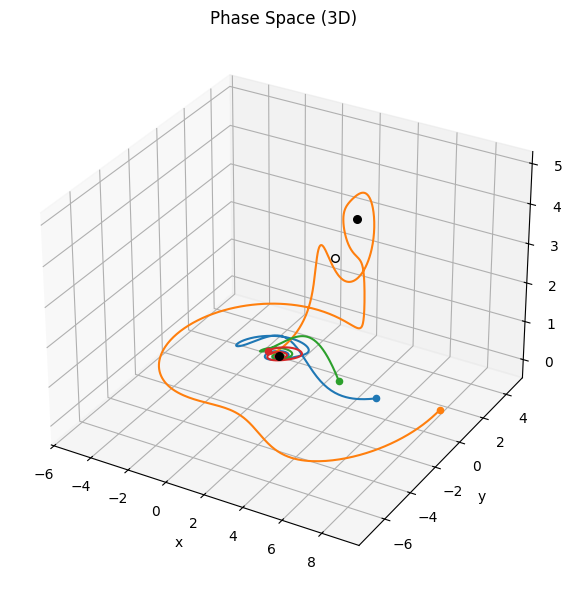

In [10]:
zeta = 0.1
alpha = 5
delta = -4
tau = 1

def lagged_driving_DHO(t, y):
    x, v, z = y
    dxdt = v
    dvdt = -2 * zeta * v - x + z
    dzdt = alpha / ((x+delta)**2+1) - z/tau
    return [dxdt, dvdt, dzdt]

#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0, 0],
    [8.5, 0.5, 0],
    [3.27, 0.4, 0],
    [-1.0, 1.0, 0]
]

roots = x_star(alpha*tau, delta)

fixed_points = []

for x in roots:
    if not np.isnan(x):
        if x == np.max(roots[~np.isnan(roots)]) or x == np.min(roots[~np.isnan(roots)]):
            fixed_points.append(('stable', (x, 0, x)))
        else:
            fixed_points.append(('unstable', (x, 0, x)))


solve_and_plot(lagged_driving_DHO, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points, plot_vectorfield=False)


In [ ]:
# Define delta range
deltas = np.linspace(-5, 0, 2000)

# Mask for valid region
mask = np.abs(deltas) >= np.sqrt(3)
deltas = deltas[mask]

# Boundaries
def lower_boundary(d):
    s = np.sqrt(d**2 - 3)
    return -2/27 * (s - 2*d)**2 * (s + d)

def upper_boundary(d):
    s = np.sqrt(d**2 - 3)
    return  2/27 * (s + 2*d)**2 * (s - d)

def lasing_threshold(d, z, t):
    q = -4*t*z**2 - 4*z - 1/t
    return (-d*(q+2)+np.sqrt((d**2+1)*(q+3)*(2*t*z+1)**2/t + d**2*(q+2)**2)) / (d+3)

lower = lower_boundary(deltas)
upper = upper_boundary(deltas)
lasing_threshold = lasing_threshold(deltas, 0.5, 1)

# Set plot limits (controls shading extent!)
alpha_min, alpha_max = 0, 10

plt.figure(figsize=(8,6))

# Shade EVERYTHING light blue first
plt.fill_between(deltas, alpha_min, alpha_max, color='lightblue', alpha=0.3,
                 label='1 fixed point')

# Overlay bistable region
plt.fill_between(deltas, lower, upper, color='orange', alpha=0.5,
                 label='3 fixed points')

# Plot boundaries on top
plt.plot(deltas, lower, 'k', linewidth=2)
plt.plot(deltas, upper, 'k', linewidth=2)
plt.plot(deltas, lasing_threshold, 'k', linewidth=2, linestyle='--')


# Labels
plt.xlabel(r'$\delta$', fontsize=12)
plt.ylabel(r'$\alpha\tau$', fontsize=12)
plt.title('Bifurcation Diagram: Lagged Lorentzian Driven DHO', fontsize=14)

# Limits
plt.xlim(deltas.min(), deltas.max())
plt.ylim(alpha_min, alpha_max)

# Legend
plt.legend()

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
def L_prime(x, alpha, delta):
    return -2*alpha*(x+delta) / ((x+delta)**2+1)**2

N_deltas = 200
N_alphas = 200
deltas = np.linspace(-5, 0, N_deltas)
alphas = np.linspace(0, 10, N_alphas)


cycle_x1 = np.zeros((len(deltas), len(alphas)))
cycle_x3 = np.zeros((len(deltas), len(alphas)))

zeta = .05
tau = 1


for i, delta in enumerate(deltas):
    for j, alpha in enumerate(alphas):
        roots = np.sort(x_star(alpha*tau, delta))
        if len(roots[~np.isnan(roots)])==3:
            if (2*zeta/tau+1)*(2*zeta+1/tau) > 1/tau - L_prime(roots[0], alpha, delta):# and a > lower_boundary(d) and a < upper_boundary(d):
                cycle_x1[i, j] +=1
            if (2*zeta/tau+1)*(2*zeta+1/tau) < 1/tau - L_prime(roots[-1], alpha, delta):# and a > lower_boundary(d) and a < upper_boundary(d):
                cycle_x3[i, j] +=1
            if alpha > lower_boundary(delta) and alpha < upper_boundary(delta):
                cycle_x1[i, j] +=.1
                cycle_x3[i, j] +=.1

plt.imshow(cycle_x1.T)
plt.ylim(0, 200)
plt.xticks(np.arange(0, N_deltas, N_deltas//10), np.round(deltas[::N_deltas//10], 1))
plt.yticks(np.arange(0, N_alphas, N_alphas//10), np.round(alphas[::N_alphas//10], 1))
plt.plot(np.arange(0, N_deltas), 20*upper_boundary(deltas), c='k')
plt.plot(np.arange(0, N_deltas), 20*lower_boundary(deltas), c='k')
plt.show()

                


C:\Users\timmerman\AppData\Local\Temp\ipykernel_9856\2879176496.py:14: RuntimeWarning: invalid value encountered in sqrt
  s = np.sqrt(d**2 - 3)
C:\Users\timmerman\AppData\Local\Temp\ipykernel_9856\2879176496.py:10: RuntimeWarning: invalid value encountered in sqrt
  s = np.sqrt(d**2 - 3)


In [ ]:


# Define your matrix
def Jacobian(alpha, delta, zeta, tau):
    roots = x_star(alpha*tau, delta)
    x = roots[~np.isnan(roots)][0]
    dLdt = L_prime(x, alpha, delta)
    J = np.array([[0   , 1      , 0     ],
                  [-1  , -2*zeta, 1     ],
                  [dLdt, 0      , -1/tau]])
    return J

# Track eigenvalues continuously
def compute_tracked_eigs(alpha_vals, delta, zeta, tau):
    eigs_all = []

    for a in alpha_vals:
        M = Jacobian(a, delta, zeta, tau)
        eigvals = np.linalg.eigvals(M)
        eigs_all.append(eigvals)

    eigs_all = np.array(eigs_all)
    print(eigs_all)
    # Initialize tracking
    tracked = np.zeros_like(eigs_all, dtype=complex)
    tracked[0] = eigs_all[0]

    for i in range(1, len(alpha_vals)):
        prev = tracked[i-1]
        curr = eigs_all[i]

        # Match by nearest distance
        remaining = list(curr)
        for j in range(3):
            distances = [abs(prev[j] - r) for r in remaining]
            idx = np.argmin(distances)
            tracked[i, j] = remaining.pop(idx)

    return tracked

[[-0.05      +0.99874922j -0.05      -0.99874922j -0.5       +0.j        ]
 [-0.05038703+0.99857505j -0.05038703-0.99857505j -0.49922594+0.j        ]
 [-0.05077664+0.99840014j -0.05077664-0.99840014j -0.49844673+0.j        ]
 [-0.05116885+0.99822449j -0.05116885-0.99822449j -0.4976623 +0.j        ]
 [-0.0515637 +0.9980481j  -0.0515637 -0.9980481j  -0.4968726 +0.j        ]
 [-0.05196122+0.99787095j -0.05196122-0.99787095j -0.49607755+0.j        ]
 [-0.05236145+0.99769305j -0.05236145-0.99769305j -0.4952771 +0.j        ]
 [-0.05276441+0.99751439j -0.05276441-0.99751439j -0.49447117+0.j        ]
 [-0.05317015+0.99733496j -0.05317015-0.99733496j -0.4936597 +0.j        ]
 [-0.05357869+0.99715475j -0.05357869-0.99715475j -0.49284261+0.j        ]
 [-0.05399008+0.99697377j -0.05399008-0.99697377j -0.49201984+0.j        ]
 [-0.05440434+0.996792j   -0.05440434-0.996792j   -0.49119131+0.j        ]
 [-0.05482152+0.99660944j -0.05482152-0.99660944j -0.49035696+0.j        ]
 [-0.05524165+0.99642608j

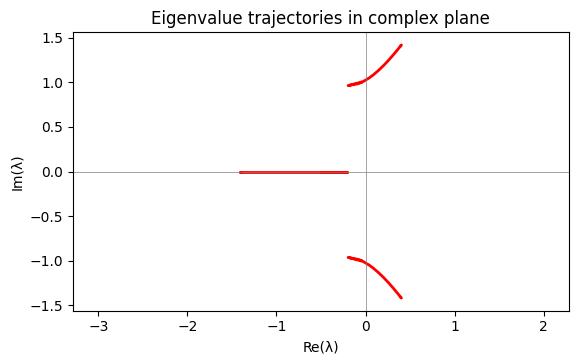

In [20]:
alpha_vals = np.linspace(0, 10, 300)

delta0, zeta0, tau0 = -4, 0.05, 2.0
eigs = compute_tracked_eigs(alpha_vals, delta0, zeta0, tau0)

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.3)

lines = []
for i in range(3):
    line, = ax.plot(eigs[:, i].real, eigs[:, i].imag, lw=2, c='r')
    lines.append(line)

ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalue trajectories in complex plane")
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal', adjustable='datalim')

In [22]:
%matplotlib qt

ax_delta = plt.axes([0.2, 0.2, 0.65, 0.03])
ax_zeta = plt.axes([0.2, 0.15, 0.65, 0.03])
ax_tau = plt.axes([0.2, 0.1, 0.65, 0.03])

slider_delta = Slider(ax_delta, 'δ', -5, 5, valinit=delta0)
slider_zeta = Slider(ax_zeta, 'ζ', -5, 5, valinit=zeta0)
slider_tau = Slider(ax_tau, 'τ', -5, 5, valinit=tau0)

def update(val):
    b = slider_delta.val
    c = slider_zeta.val
    d = slider_tau.val

    eigs = compute_tracked_eigs(alpha_vals, b, c, d)

    for i in range(3):
        lines[i].set_data(eigs[:, i].real, eigs[:, i].imag)

    ax.relim()
    ax.autoscale_view()

    fig.canvas.draw_idle()

slider_delta.on_changed(update)
slider_zeta.on_changed(update)
slider_tau.on_changed(update)

plt.show()

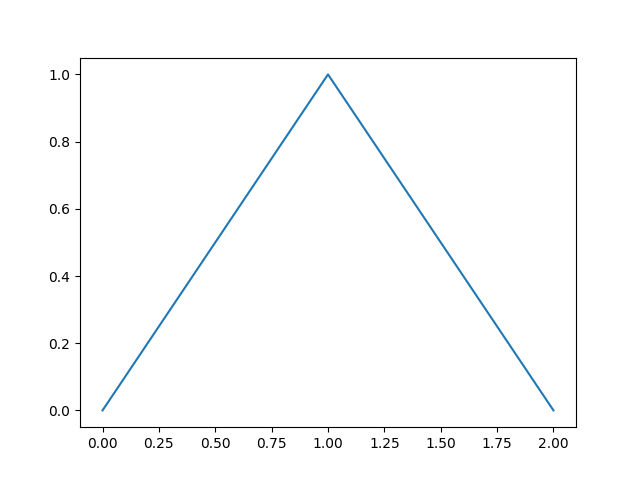

: 

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([0,1,2], [0,1,0])
plt.show()

In [23]:
import ipywidgets as widgets
from IPython.display import display

alpha_vals = np.linspace(0, 10, 300)

def plot_eigs(b=1.0, c=1.0, d=1.0):
    eigs = compute_tracked_eigs(alpha_vals, b, c, d)

    plt.figure(figsize=(5,5))
    for i in range(3):
        plt.plot(eigs[:, i].real, eigs[:, i].imag)

    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.title("Eigenvalue trajectories")
    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.show()

widgets.interact(
    plot_eigs,
    b=(-5, 5, 0.1),
    c=(-5, 5, 0.1),
    d=(-5, 5, 0.1),
);

interactive(children=(FloatSlider(value=1.0, description='b', max=5.0, min=-5.0), FloatSlider(value=1.0, descr…